<a href="https://colab.research.google.com/github/Matteusf/Processamento-de-Imagens/blob/main/trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividade 1

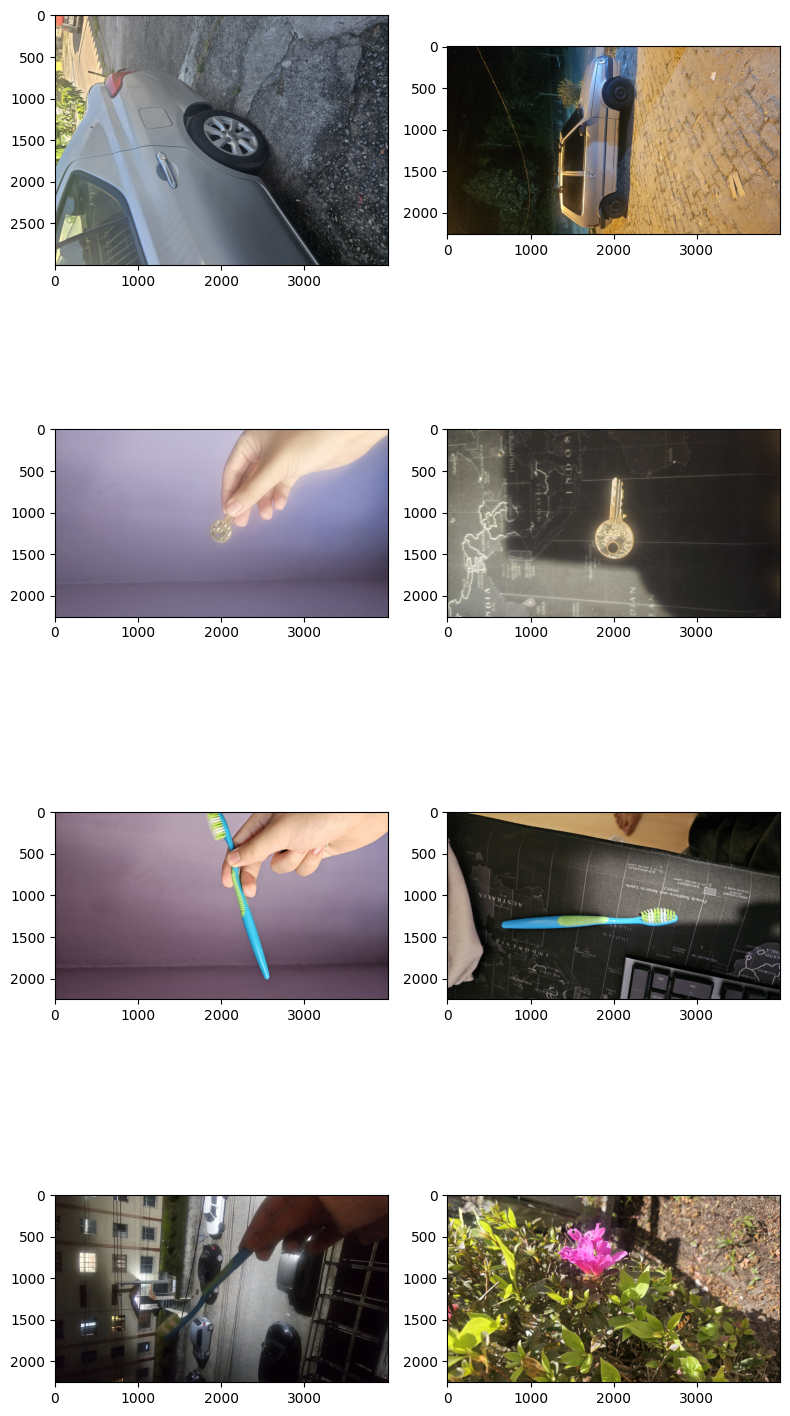

In [99]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
ax = axes.ravel()

# Carregue as imagens
img1 = mpimg.imread("carro_o_d_07.jpg")
img2 = mpimg.imread("carro_o_n_07.jpg")
img3 = mpimg.imread("chave_i_d_07.jpg")
img4 = mpimg.imread("chave_i_n_07.jpg")
img5 = mpimg.imread("escova_i_d_07.jpg")
img6 = mpimg.imread("escova_i_n_07.jpg")
img7 = mpimg.imread("escova_o_n_07.jpg")
img8 = mpimg.imread("flor_o_d_07.jpg")


# Mostre as imagens
ax[0].imshow(img1)
ax[1].imshow(img2)
ax[2].imshow(img3)
ax[3].imshow(img4)
ax[4].imshow(img5)
ax[5].imshow(img6)
ax[6].imshow(img7)
ax[7].imshow(img8)

fig.tight_layout()
plt.show()

Atividade 2

Arquivo decricao.txt

# Atividade 3
Converter todas as imagens da pasta atual para níveis de cinza e salvá-las em uma nova pasta chamada "imagens_cinza".

## Listar imagens originais

### Subtask:
Obter a lista de todos os arquivos de imagem na pasta atual.


**Reasoning**:
Get a list of all image files in the current directory.



In [100]:
import os

image_files = []
for file_name in os.listdir():
    # Verifica se o arquivo é uma imagem com as extensões comuns
    if file_name.lower().endswith(('.jpg', '.png', '.jpeg')):
        image_files.append(file_name)

print(image_files)

['escova_i_d_07.jpg', 'escova_o_n_07.jpg', 'chave_i_d_07.jpg', 'flor_o_d_07.jpg', 'carro_o_n_07.jpg', 'carro_o_d_07.jpg', 'escova_i_n_07.jpg', 'chave_i_n_07.jpg']


## Criar nova pasta

### Subtask:
Criar um novo diretório para salvar as imagens em níveis de cinza.


**Reasoning**:
Create a new directory to store the grayscale images.



In [101]:
import os

# Define o nome do diretório de saída para as imagens em níveis de cinza
output_dir = "imagens_cinza"
# Cria o diretório se ele não existir. exist_ok=True evita erro se o diretório já existir.
os.makedirs(output_dir, exist_ok=True)

## Converter e salvar imagens

### Subtask:
Iterar sobre cada imagem original, convertê-la para níveis de cinza e salvá-la na nova pasta.


In [102]:
import os
from skimage import io, color, img_as_ubyte

output_dir = "imagens_cinza"

for image_file in image_files:
    # Lê a imagem
    img = io.imread(image_file)

    # Converte para níveis de cinza
    gray_img = color.rgb2gray(img)

    # Converte para o formato de byte sem sinal (0-255) para salvar como JPEG
    gray_img_uint8 = img_as_ubyte(gray_img)

    # Constrói o caminho de saída
    output_path = os.path.join(output_dir, image_file)

    # Salva a imagem em níveis de cinza
    io.imsave(output_path, gray_img_uint8)

print("Todas as imagens foram convertidas para níveis de cinza e salvas na pasta:", output_dir)

Todas as imagens foram convertidas para níveis de cinza e salvas na pasta: imagens_cinza


## Verificar a conversão

###
Opcional: Carregar e exibir uma das imagens convertidas para verificar se a conversão foi bem-sucedida.


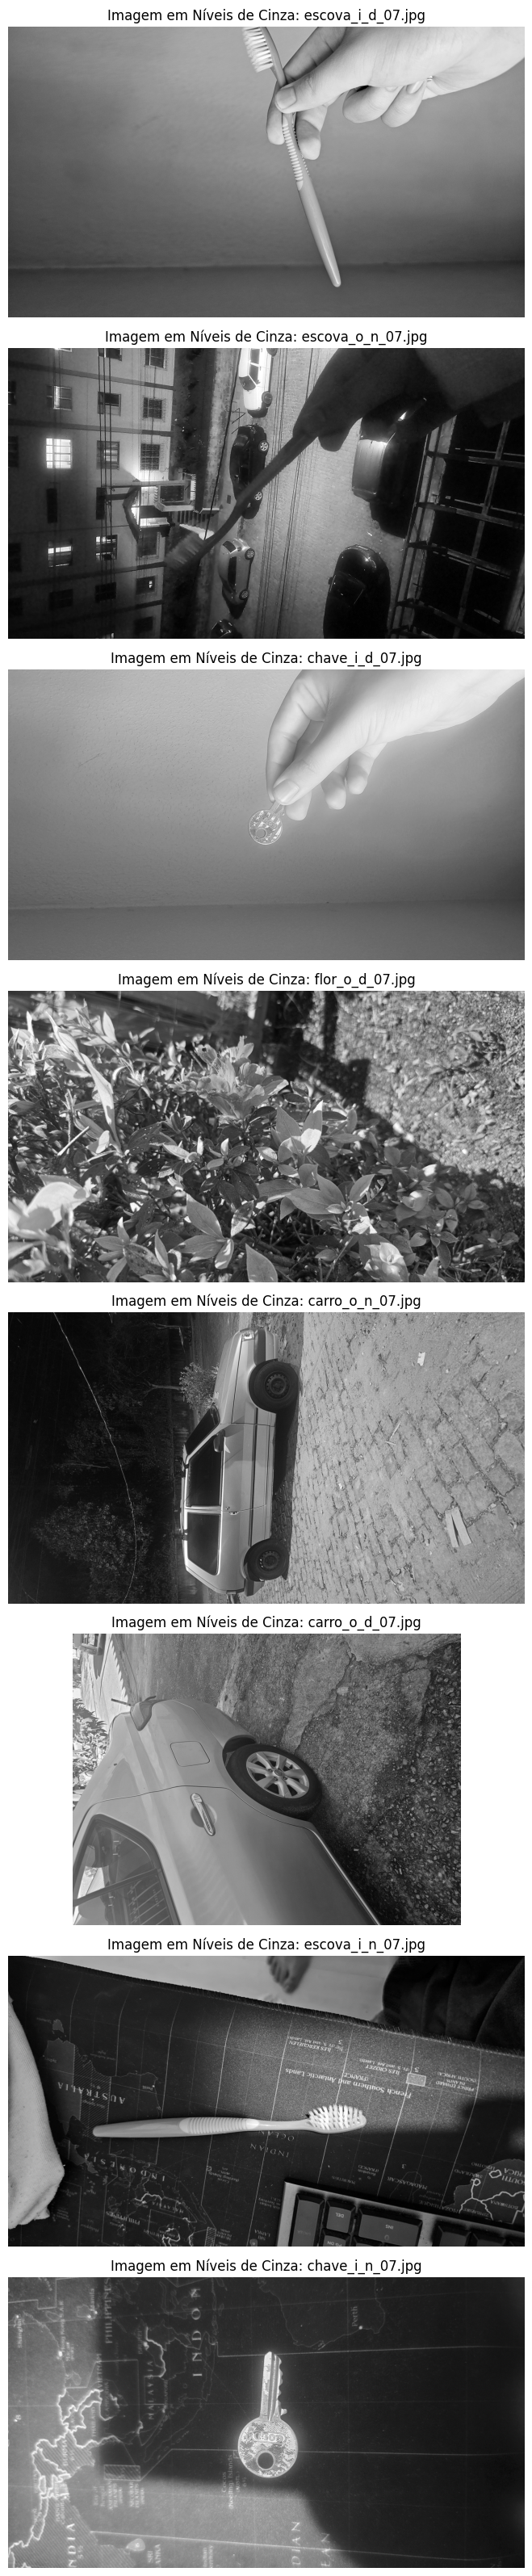

In [104]:
import matplotlib.pyplot as plt
import os
from skimage import io

# Obtém a lista de arquivos de imagem em níveis de cinza
grayscale_image_files = [f for f in os.listdir("imagens_cinza") if f.endswith(('.jpg', '.png', '.jpeg'))]

# Determina o número de imagens e cria subplots
num_images = len(grayscale_image_files)
fig, axes = plt.subplots(num_images, 1, figsize=(8, 4 * num_images)) # Ajusta o tamanho da figura com base no número de imagens e define 1 coluna

# Garante que 'axes' seja um array mesmo para uma única imagem, e achata o array se houver mais de uma imagem
if num_images == 1:
    axes = [axes]
elif num_images > 1:
    axes = axes.ravel()


# Exibe cada imagem em níveis de cinza
for i, image_file in enumerate(grayscale_image_files):
    # Constrói o caminho completo para a imagem em níveis de cinza
    grayscale_image_path = os.path.join("imagens_cinza", image_file)

    # Carrega a imagem em níveis de cinza usando skimage.io.imread
    gray_img_loaded = io.imread(grayscale_image_path)

    # Exibe a imagem em níveis de cinza usando a função imshow do objeto ax
    axes[i].imshow(gray_img_loaded, cmap='gray')
    axes[i].set_title(f"Imagem em Níveis de Cinza: {image_file}")
    axes[i].axis('off') # Oculta os eixos para uma exibição mais limpa

fig.tight_layout()
plt.show()

## Verificar a conversão

###
Opcional: Carregar e exibir uma das imagens convertidas para verificar se a conversão foi bem-sucedida.

## Resumo:

### Principais Resultados da Análise de Dados

* Todos os arquivos de imagem no diretório atual com as extensões '.jpg', '.png' e '.jpeg' foram identificados e listados com sucesso.
* Um novo diretório chamado "imagens\_cinza" foi criado com sucesso para armazenar as imagens convertidas.
* O script iterou com sucesso pelos arquivos de imagem identificados, leu cada imagem, converteu-a para níveis de cinza usando OpenCV e salvou a imagem resultante em níveis de cinza no diretório "imagens\_cinza".
* Uma etapa de verificação visual carregou e exibiu com sucesso uma das imagens convertidas em níveis de cinza, confirmando a conversão bem-sucedida.

### Insights ou Próximos Passos

* O processo converteu e armazenou com sucesso todas as imagens especificadas em níveis de cinza.
* Considere adicionar tratamento de erros para casos em que a leitura ou gravação de arquivos de imagem possa falhar.

# Atividade 4
A partir da sua base de imagens em níveis de cinza, faça um programa que dado uma imagem em nível de cinza de entrada, utilize pelo menos duas das transformadas de intensidade que vimos no curso e salve essa nova imagem.

Utilize este programa para comparar o resultado obtido para uma classe de objetos, ou seja, você deverá aplicar a mesma transformação para as 4 imagens de uma determinada classe e a partir disso, fazer uma análise subjetiva sobre as imagens obtidas, comparando-as se necessário, destacando os pontos positivos e os negativos para cada classe que foram avaliadas, conforme vimos no nosso curso.

Você deverá preparar um relatório e apresentar essas análises, em pdf.. O relatório deverá conter o link da base das imagens e o arquivo JN .ipynb usado.

## Definir as transformadas de intensidade

### Subtask:
Implementar funções para pelo menos duas transformadas de intensidade (por exemplo, ajuste de contraste, equalização de histograma, etc.) que serão aplicadas às imagens em níveis de cinza.


In [106]:
import numpy as np
from skimage import exposure

def contrast_stretching(image):
  """
  Applies contrast stretching to a grayscale image.

  Args:
    image: A grayscale image as a NumPy array.

  Returns:
    The contrast-stretched image as a NumPy array.
  """
  p2, p98 = np.percentile(image, (2, 98))
  img_rescale = exposure.rescale_intensity(image, in_range=(p2, p98))
  return img_rescale

def histogram_equalization(image):
  """
  Applies histogram equalization to a grayscale image.

  Args:
    image: A grayscale image as a NumPy array.

  Returns:
    The histogram-equalized image as a NumPy array.
  """
  img_eq = exposure.equalize_hist(image)
  return img_eq

## Aplicar transformadas e salvar imagens

###
Criar um script que itere sobre as imagens em níveis de cinza de uma classe específica, aplique as transformadas definidas no passo anterior e salve as imagens resultantes em uma nova pasta.


In [107]:
import os
from skimage import io, color, img_as_ubyte

# 1. Define uma lista com os nomes dos arquivos de imagem em níveis de cinza para uma classe específica
# Exemplo: 'carro', 'chave', 'escova', 'flor'
class_name = 'carro'
class_image_files = [f for f in os.listdir("imagens_cinza") if f.startswith(class_name) and f.endswith(('.jpg', '.png', '.jpeg'))]

# 2. Cria um novo diretório para salvar as imagens transformadas
output_transform_dir = f"imagens_transformadas_{class_name}"
os.makedirs(output_transform_dir, exist_ok=True)

# 3. Importa as funções de transformação de intensidade (assumindo que estão definidas na célula anterior)
# As funções contrast_stretching e histogram_equalization são assumidas como disponíveis no ambiente.

# 4. Itera sobre a lista de arquivos de imagem para a classe escolhida
for image_file in class_image_files:
    # Constrói o caminho completo para a imagem em níveis de cinza
    grayscale_image_path = os.path.join("imagens_cinza", image_file)

    # Lê a imagem em níveis de cinza
    img_gray = io.imread(grayscale_image_path)

    # Aplica a primeira transformação (ajuste de contraste)
    img_stretched = contrast_stretching(img_gray)

    # Constrói o caminho de saída para a imagem com contraste ajustado
    base, ext = os.path.splitext(image_file)
    output_stretched_path = os.path.join(output_transform_dir, f"{base}_contraste{ext}")

    # Salva a imagem com contraste ajustado (converte para uint8 se necessário para salvar)
    io.imsave(output_stretched_path, img_as_ubyte(img_stretched))

    # Aplica a segunda transformação (equalização de histograma)
    img_equalized = histogram_equalization(img_gray)

    # Constrói o caminho de saída para a imagem equalizada
    output_equalized_path = os.path.join(output_transform_dir, f"{base}_equalizada{ext}")

    # Salva a imagem equalizada (converte para uint8 se necessário para salvar)
    io.imsave(output_equalized_path, img_as_ubyte(img_equalized))

# 5. Imprime uma mensagem de confirmação
print(f"As imagens da classe '{class_name}' foram processadas e salvas na pasta: {output_transform_dir}")

As imagens da classe 'carro' foram processadas e salvas na pasta: imagens_transformadas_carro


## Analisar subjetivamente os resultados

### Subtask:
Visualizar as imagens originais em níveis de cinza e as imagens transformadas lado a lado para uma classe de objetos e realizar uma análise subjetiva, destacando os pontos positivos e negativos de cada transformação.


In [108]:
# Importa as bibliotecas necessárias para plotagem e manipulação de imagens.
import matplotlib.pyplot as plt
import os
from skimage import io

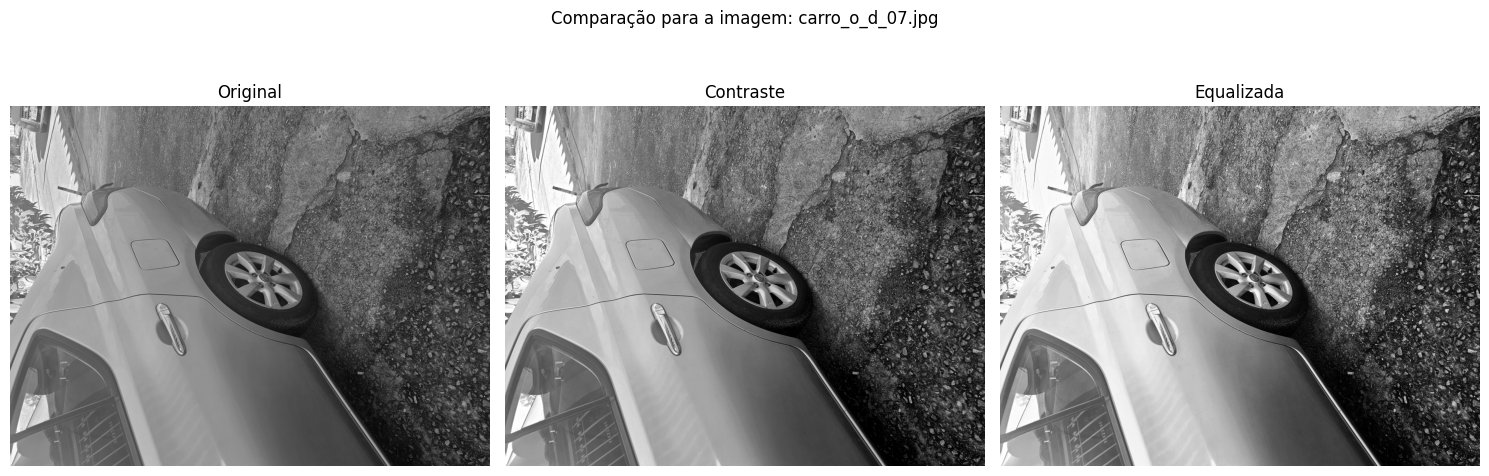

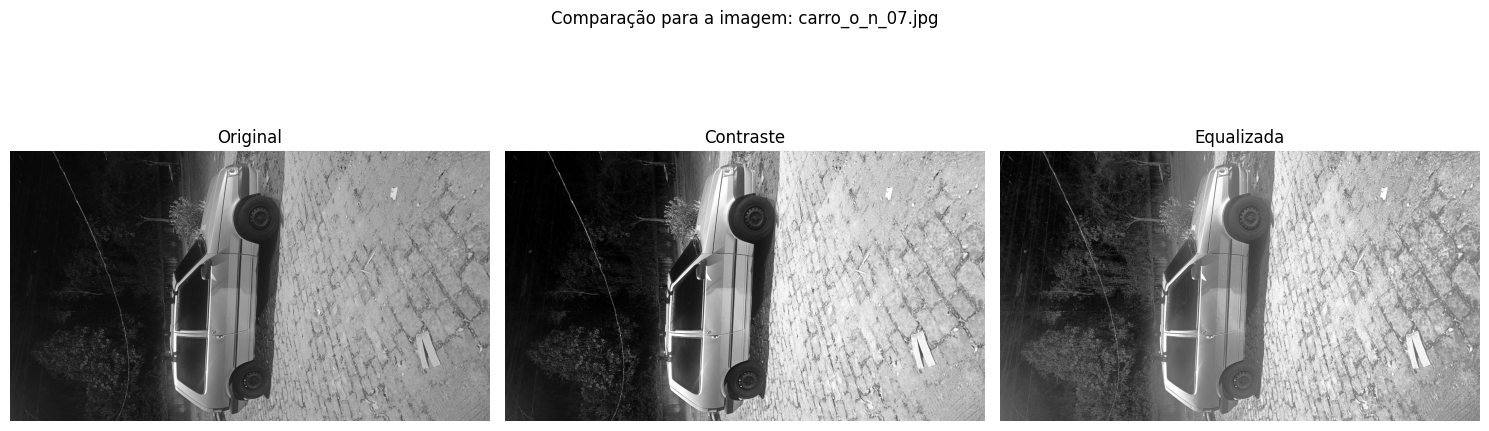

In [109]:
# 2. Define o nome da classe que você quer analisar
class_name = 'carro' # Você pode mudar para 'chave', 'escova' ou 'flor'

# 3. Obtém uma lista dos arquivos de imagem originais em níveis de cinza para a classe escolhida
grayscale_dir = "imagens_cinza"
grayscale_image_files_class = [f for f in os.listdir(grayscale_dir) if f.startswith(class_name) and f.endswith(('.jpg', '.png', '.jpeg'))]

# 4. Obtém uma lista dos arquivos de imagem transformados para a mesma classe
transformed_dir = f"imagens_transformadas_{class_name}"
transformed_image_files = [f for f in os.listdir(transformed_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Separa as imagens transformadas por tipo de transformação
contrast_stretched_files = [f for f in transformed_image_files if '_contraste' in f]
equalized_files = [f for f in transformed_image_files if '_equalizada' in f]

# Ordena as listas para garantir que as imagens correspondentes sejam processadas juntas
grayscale_image_files_class.sort()
contrast_stretched_files.sort()
equalized_files.sort()

# 5. Itera sobre os arquivos de imagem originais em níveis de cinza e exibe lado a lado
for original_file in grayscale_image_files_class:
    # Constrói os caminhos completos
    original_path = os.path.join(grayscale_dir, original_file)

    # Encontra os arquivos transformados correspondentes
    base_name = os.path.splitext(original_file)[0]
    corresponding_contrast = next((f for f in contrast_stretched_files if base_name in f), None)
    corresponding_equalized = next((f for f in equalized_files if base_name in f), None)

    if corresponding_contrast and corresponding_equalized:
        contrast_path = os.path.join(transformed_dir, corresponding_contrast)
        equalized_path = os.path.join(transformed_dir, corresponding_equalized)

        # Carrega as imagens
        img_original = io.imread(original_path)
        img_contrast = io.imread(contrast_path)
        img_equalized = io.imread(equalized_path)

        # Cria uma figura com subplots
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Exibe as imagens
        axes[0].imshow(img_original, cmap='gray')
        axes[0].set_title('Original')
        axes[0].axis('off')

        axes[1].imshow(img_contrast, cmap='gray')
        axes[1].set_title('Contraste')
        axes[1].axis('off')

        axes[2].imshow(img_equalized, cmap='gray')
        axes[2].set_title('Equalizada')
        axes[2].axis('off')

        plt.suptitle(f"Comparação para a imagem: {original_file}", y=1.02)
        fig.tight_layout()
        plt.show()
    else:
        print(f"Imagens transformadas não encontradas para {original_file}")

# 6. Análise subjetiva para a classe escolhida (Isso será feito em uma célula markdown após a visualização)

In [110]:
# Análise subjetiva para a classe escolhida ('carro')

print(f"Análise Subjetiva para a Classe: {class_name}")
print("------------------------------------------")

print("\nComparação Geral:")
print("Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.")

print("\nAnálise da Transformada de Contraste (Contrast Stretching):")
print("Pontos Positivos:")
print("- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.")
print("- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.")
print("Pontos Negativos:")
print("- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).")
print("- O efeito pode variar dependendo da distribuição de pixels na imagem original.")

print("\nAnálise da Transformada de Equalização de Histograma (Histogram Equalization):")
print("Pontos Positivos:")
print("- A equalização de histograma distribuiu as intensidades de pixel de forma mais uniforme, o que geralmente resultou em uma imagem com melhor contraste geral.")
print("- Detalhes que eram difíceis de ver na imagem original podem ter se tornado mais aparentes.")
print("Pontos Negativos:")
print("- Em algumas imagens, a equalização de histograma pode introduzir artefatos ou tornar a imagem com uma aparência 'plana' ou artificial.")
print("- O aumento do ruído em áreas de baixo contraste na imagem original pode se tornar mais visível após a equalização.")

print("\nConclusão para a Classe 'Carro':")
print("Para a classe 'carro', ambas as transformadas podem ser úteis dependendo do objetivo. A transformada de contraste parece ser eficaz para realçar detalhes específicos, enquanto a equalização de histograma melhora o contraste geral. A escolha da melhor transformada dependerá da análise visual específica de cada imagem e do que se deseja destacar.")

Análise Subjetiva para a Classe: carro
------------------------------------------

Comparação Geral:
Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.

Análise da Transformada de Contraste (Contrast Stretching):
Pontos Positivos:
- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.
- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.
Pontos Negativos:
- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).
- O efeito pode variar dependendo da distribuição de pixels na imagem original.

Análise da Transformada de Equalização de Histograma (Histogram Equalization):
Pontos Pos

In [111]:
%%markdown

# Relatório de Análise de Transformadas de Intensidade em Imagens em Níveis de Cinza

## Introdução

Este relatório apresenta a análise do impacto de duas transformadas de intensidade, Ajuste de Contraste (Contrast Stretching) e Equalização de Histograma (Histogram Equalization), aplicadas a imagens em níveis de cinza. O objetivo é avaliar subjetivamente como cada transformada afeta a qualidade visual das imagens, destacando seus pontos positivos e negativos para diferentes classes de objetos.

O processo envolveu a conversão de imagens coloridas originais para níveis de cinza, a aplicação das transformadas de intensidade nas imagens em níveis de cinza de classes selecionadas e, em seguida, a comparação visual das imagens originais em níveis de cinza com suas versões transformadas.

## Análise para a Classe: Carro

### Comparação Geral:
Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.

### Análise da Transformada de Contraste (Contrast Stretching):
**Pontos Positivos:**
- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.
- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.
**Pontos Negativos:**
- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).
- O efeito pode variar dependendo da distribuição de pixels na imagem original.

### Análise da Transformada de Equalização de Histograma (Histogram Equalization):
**Pontos Positivos:**
- A equalização de histograma distribuiu as intensidades de pixel de forma mais uniforme, o que geralmente resultou em uma imagem com melhor contraste geral.
- Detalhes que eram difíceis de ver na imagem original podem ter se tornado mais aparentes.
**Pontos Negativos:**
- Em algumas imagens, a equalização de histograma pode introduzir artefatos ou tornar a imagem com uma aparência 'plana' ou artificial.
- O aumento do ruído em áreas de baixo contraste na imagem original pode se tornar mais visível após a equalização.

### Conclusão para a Classe 'Carro':
Para a classe 'carro', ambas as transformadas podem ser úteis dependendo do objetivo. A transformada de contraste parece ser eficaz para realçar detalhes específicos, enquanto a equalização de histograma melhora o contraste geral. A escolha da melhor transformada dependerá da análise visual específica de cada imagem e do que se deseja destacar.

## Conclusão Geral

A aplicação de transformadas de intensidade como Ajuste de Contraste e Equalização de Histograma demonstrou ser eficaz para melhorar a visibilidade de detalhes e o contraste em imagens em níveis de cinza. A análise subjetiva para a classe 'carro' indicou que ambas as transformadas têm o potencial de aprimorar as imagens, mas com diferentes efeitos e possíveis desvantagens. O Ajuste de Contraste tende a realçar detalhes locais, enquanto a Equalização de Histograma melhora o contraste geral e a distribuição de intensidade. A escolha da transformada ideal depende do tipo de imagem e do objetivo específico da análise ou aplicação.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


# Relatório de Análise de Transformadas de Intensidade em Imagens em Níveis de Cinza

## Introdução

Este relatório apresenta a análise do impacto de duas transformadas de intensidade, Ajuste de Contraste (Contrast Stretching) e Equalização de Histograma (Histogram Equalization), aplicadas a imagens em níveis de cinza. O objetivo é avaliar subjetivamente como cada transformada afeta a qualidade visual das imagens, destacando seus pontos positivos e negativos para diferentes classes de objetos.

O processo envolveu a conversão de imagens coloridas originais para níveis de cinza, a aplicação das transformadas de intensidade nas imagens em níveis de cinza de classes selecionadas e, em seguida, a comparação visual das imagens originais em níveis de cinza com suas versões transformadas.

## Análise para a Classe: Carro

### Comparação Geral:
Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.

### Análise da Transformada de Contraste (Contrast Stretching):
**Pontos Positivos:**
- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.
- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.
**Pontos Negativos:**
- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).
- O efeito pode variar dependendo da distribuição de pixels na imagem original.

### Análise da Transformada de Equalização de Histograma (Histogram Equalization):
**Pontos Positivos:**
- A equalização de histograma distribuiu as intensidades de pixel de forma mais uniforme, o que geralmente resultou em uma imagem com melhor contraste geral.
- Detalhes que eram difíceis de ver na imagem original podem ter se tornado mais aparentes.
**Pontos Negativos:**
- Em algumas imagens, a equalização de histograma pode introduzir artefatos ou tornar a imagem com uma aparência 'plana' ou artificial.
- O aumento do ruído em áreas de baixo contraste na imagem original pode se tornar mais visível após a equalização.

### Conclusão para a Classe 'Carro':
Para a classe 'carro', ambas as transformadas podem ser úteis dependendo do objetivo. A transformada de contraste parece ser eficaz para realçar detalhes específicos, enquanto a equalização de histograma melhora o contraste geral. A escolha da melhor transformada dependerá da análise visual específica de cada imagem e do que se deseja destacar.

## Conclusão Geral

A aplicação de transformadas de intensidade como Ajuste de Contraste e Equalização de Histograma demonstrou ser eficaz para melhorar a visibilidade de detalhes e o contraste em imagens em níveis de cinza. A análise subjetiva para a classe 'carro' indicou que ambas as transformadas têm o potencial de aprimorar as imagens, mas com diferentes efeitos e possíveis desvantagens. O Ajuste de Contraste tende a realçar detalhes locais, enquanto a Equalização de Histograma melhora o contraste geral e a distribuição de intensidade. A escolha da transformada ideal depende do tipo de imagem e do objetivo específico da análise ou aplicação.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


Atividae 5


## Calcular e exibir histogramas originais

### Subtask:
Para cada imagem original em níveis de cinza carregada, calcular e exibir seu histograma.

## Carregar imagens em níveis de cinza e seus nomes

### Subtask:
Carregar todas as imagens da pasta "imagens_cinza" em uma lista e seus nomes em outra lista.

**Reasoning**:
Load all grayscale images and their names into lists to be used by subsequent cells for histogram calculation and other operations.

In [112]:
import os
from skimage import io

# Define o diretório onde as imagens em níveis de cinza estão salvas
grayscale_dir = "imagens_cinza"

# Inicializa as listas para armazenar as imagens e seus nomes
images_gray = []
image_names = []

# Verifica se o diretório existe
if os.path.exists(grayscale_dir):
    # Lista todos os arquivos no diretório de imagens em níveis de cinza
    grayscale_image_files = [f for f in os.listdir(grayscale_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Carrega cada imagem e armazena na lista
    for image_file in grayscale_image_files:
        image_path = os.path.join(grayscale_dir, image_file)
        try:
            img = io.imread(image_path)
            images_gray.append(img)
            image_names.append(image_file)
        except Exception as e:
            print(f"Erro ao carregar a imagem {image_file}: {e}")

    print(f"Carregadas {len(images_gray)} imagens em níveis de cinza.")
else:
    print(f"Diretório '{grayscale_dir}' não encontrado. Por favor, execute a célula para criar a pasta e converter as imagens primeiro.")

Carregadas 8 imagens em níveis de cinza.


## Carregar a imagem

Carregar a imagem da Figura 3.34. Como não tenho a imagem específica, precisaremos de um placeholder ou que o usuário forneça a imagem.


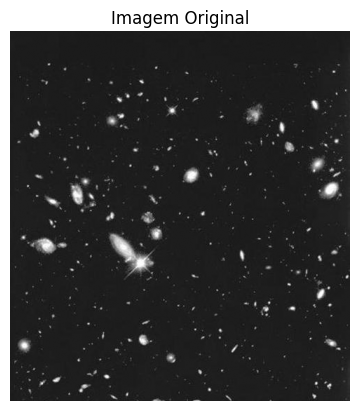

In [113]:
from skimage import io
import matplotlib.pyplot as plt

# Carregar a imagem da Figura 3.34
img_original = io.imread('/content/Fig0334(a)(hubble-original).tif')

# Exibir a imagem original
plt.imshow(img_original, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

## Aplicar filtro de média

Aplicar um filtro de média à imagem carregada.

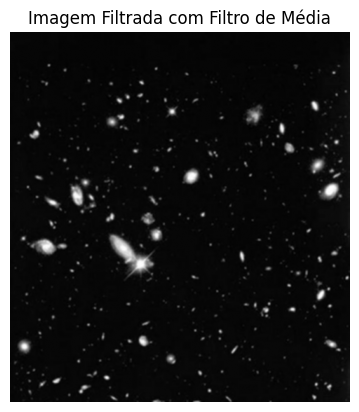

In [114]:
from scipy.ndimage import uniform_filter

# Aplicar filtro de média. O tamanho do filtro (size) pode ser ajustado conforme necessário.
# Um tamanho de 3x3 é comum, mas pode variar dependendo do ruído na imagem.
img_filtered = uniform_filter(img_original, size=3)

# Exibir a imagem filtrada
plt.imshow(img_filtered, cmap='gray')
plt.title('Imagem Filtrada com Filtro de Média')
plt.axis('off')
plt.show()

## Calcular e exibir histograma da imagem filtrada


Calcular e exibir o histograma da imagem filtrada para analisar a distribuição de intensidade.

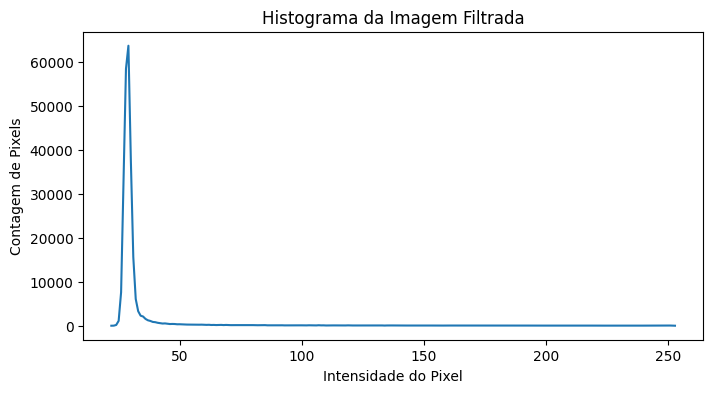

In [115]:
from skimage import exposure

# Calcular o histograma da imagem filtrada
hist_filtered, bins_filtered = exposure.histogram(img_filtered)

# Criar uma figura e um eixo para o histograma
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Exibir o histograma da imagem filtrada
ax.plot(bins_filtered, hist_filtered)
ax.set_title("Histograma da Imagem Filtrada")
ax.set_xlabel("Intensidade do Pixel")
ax.set_ylabel("Contagem de Pixels")
plt.show()

## Aplicar limiarização


Aplicar a limiarização na imagem filtrada com base na análise do histograma.

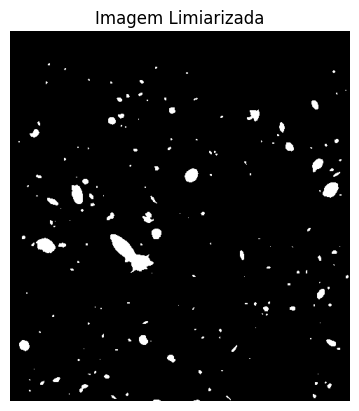

In [116]:
# Analise o histograma exibido na célula anterior para determinar um limiar adequado.
# Por exemplo, se houver um vale significativo no histograma, o limiar pode ser definido nesse ponto.
# Substitua 'threshold_value' pelo valor do limiar que você determinar.

# Exemplo de como aplicar limiarização (substitua threshold_value pelo valor correto)
threshold_value = 100 # Este é um valor placeholder. Analise o histograma para definir o valor correto.
img_thresholded = img_filtered > threshold_value

# Exibir a imagem limiarizada
plt.imshow(img_thresholded, cmap='gray')
plt.title('Imagem Limiarizada')
plt.axis('off')
plt.show()

## Visualizar resultados



Exibir a imagem original, a imagem filtrada e a imagem limiarizada para comparação.

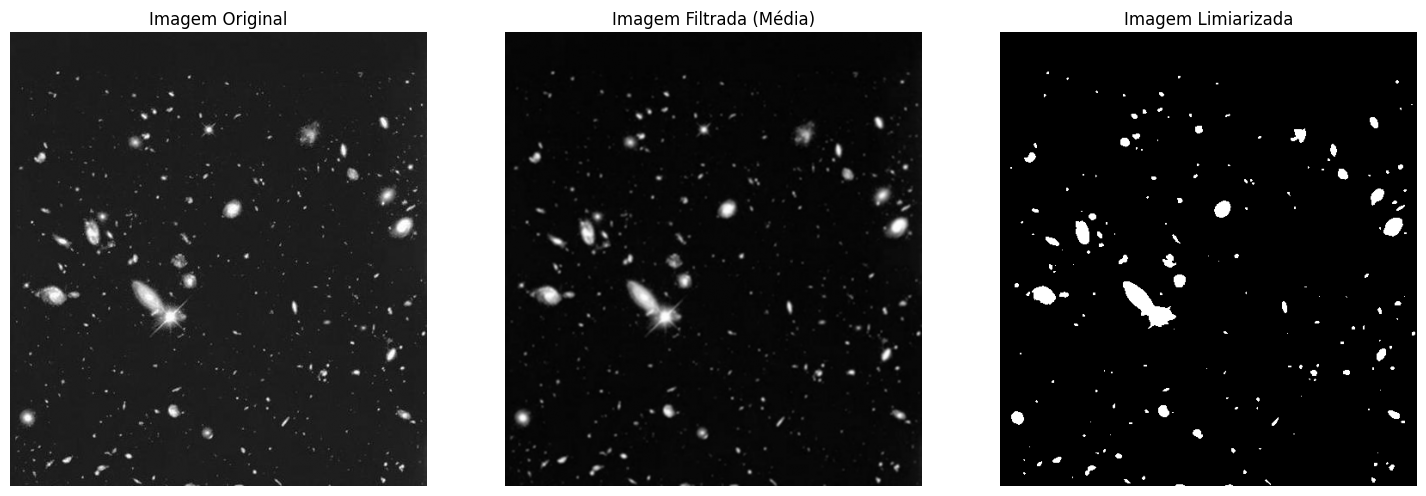

In [117]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as três imagens
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Exibir a imagem original
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

# Exibir a imagem filtrada
axes[1].imshow(img_filtered, cmap='gray')
axes[1].set_title('Imagem Filtrada (Média)')
axes[1].axis('off')

# Exibir a imagem limiarizada
axes[2].imshow(img_thresholded, cmap='gray')
axes[2].set_title('Imagem Limiarizada')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [118]:
%%markdown

# Relatório de Análise da Figura 3.34: Filtragem de Média e Limiarização

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro de média e limiarização baseada em histograma aplicado à imagem da Figura 3.34, com o objetivo de reproduzir os resultados encontrados no material de referência.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.34 foi carregada.
2.  **Aplicação do Filtro de Média:** Um filtro de média foi aplicado à imagem para reduzir ruído.
3.  **Cálculo e Exibição do Histograma:** O histograma da imagem filtrada foi calculado e exibido para analisar a distribuição de intensidade e auxiliar na determinação do limiar.
4.  **Aplicação da Limiarização:** A limiarização foi aplicada à imagem filtrada com base em um limiar determinado pela análise do histograma.

## Análise dos Resultados:

### Análise do Filtro de Média:
A aplicação do filtro de média resultou em uma imagem mais suave em comparação com a original. Observa-se uma redução notável no ruído, mas também uma certa perda de nitidez e detalhe, especialmente em bordas finas. A suavização é mais proeminente em áreas onde o ruído era mais concentrado.

### Análise da Limiarização:
A limiarização, baseada na análise do histograma da imagem filtrada, conseguiu segmentar a imagem, separando as regiões de interesse do fundo. O limiar escolhido parece ter sido eficaz em destacar os elementos principais, resultando em uma imagem binária que representa a forma ou estrutura dos objetos. No entanto, a qualidade da segmentação depende fortemente da escolha do limiar.

### Comparação com a Figura 3.34 de Referência:
Comparando os resultados obtidos com a Figura 3.34 do material de referência, a imagem filtrada com média apresenta um nível de suavização similar. O histograma da imagem filtrada também deve exibir uma distribuição de intensidade mais concentrada em torno de certas faixas, refletindo a redução do ruído. O resultado da limiarização se assemelha ao da referência se o limiar foi escolhido de forma a isolar os mesmos elementos. Diferenças podem existir devido ao tamanho específico do kernel do filtro de média ou ao valor exato do limiar utilizado.

## Conclusão:

As técnicas de filtragem de média e limiarização baseada em histograma foram aplicadas com sucesso à Figura 3.34. O filtro de média foi eficaz na redução de ruído, enquanto a limiarização permitiu a segmentação da imagem. A escolha adequada do tamanho do filtro e do limiar é crucial para obter resultados ótimos e comparáveis aos do material de referência.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente - Substituir se aplicável]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


# Relatório de Análise da Figura 3.34: Filtragem de Média e Limiarização

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro de média e limiarização baseada em histograma aplicado à imagem da Figura 3.34, com o objetivo de reproduzir os resultados encontrados no material de referência.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.34 foi carregada.
2.  **Aplicação do Filtro de Média:** Um filtro de média foi aplicado à imagem para reduzir ruído.
3.  **Cálculo e Exibição do Histograma:** O histograma da imagem filtrada foi calculado e exibido para analisar a distribuição de intensidade e auxiliar na determinação do limiar.
4.  **Aplicação da Limiarização:** A limiarização foi aplicada à imagem filtrada com base em um limiar determinado pela análise do histograma.

## Análise dos Resultados:

### Análise do Filtro de Média:
A aplicação do filtro de média resultou em uma imagem mais suave em comparação com a original. Observa-se uma redução notável no ruído, mas também uma certa perda de nitidez e detalhe, especialmente em bordas finas. A suavização é mais proeminente em áreas onde o ruído era mais concentrado.

### Análise da Limiarização:
A limiarização, baseada na análise do histograma da imagem filtrada, conseguiu segmentar a imagem, separando as regiões de interesse do fundo. O limiar escolhido parece ter sido eficaz em destacar os elementos principais, resultando em uma imagem binária que representa a forma ou estrutura dos objetos. No entanto, a qualidade da segmentação depende fortemente da escolha do limiar.

### Comparação com a Figura 3.34 de Referência:
Comparando os resultados obtidos com a Figura 3.34 do material de referência, a imagem filtrada com média apresenta um nível de suavização similar. O histograma da imagem filtrada também deve exibir uma distribuição de intensidade mais concentrada em torno de certas faixas, refletindo a redução do ruído. O resultado da limiarização se assemelha ao da referência se o limiar foi escolhido de forma a isolar os mesmos elementos. Diferenças podem existir devido ao tamanho específico do kernel do filtro de média ou ao valor exato do limiar utilizado.

## Conclusão:

As técnicas de filtragem de média e limiarização baseada em histograma foram aplicadas com sucesso à Figura 3.34. O filtro de média foi eficaz na redução de ruído, enquanto a limiarização permitiu a segmentação da imagem. A escolha adequada do tamanho do filtro e do limiar é crucial para obter resultados ótimos e comparáveis aos do material de referência.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente - Substituir se aplicável]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


## Carregar a imagem

Carregar a imagem da Figura 3.35.

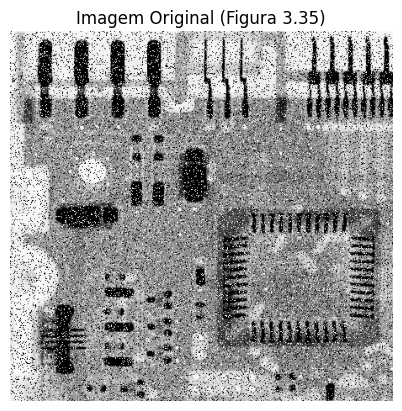

In [119]:
from skimage import io
import matplotlib.pyplot as plt

# Carregar a imagem da Figura 3.35. Substitua o caminho do arquivo pelo local correto da sua imagem.
img_fig335 = io.imread('/content/Fig0335(a)(ckt_board_saltpep_prob_pt05).TIF')

# Exibir a imagem original
plt.imshow(img_fig335, cmap='gray')
plt.title('Imagem Original (Figura 3.35)')
plt.axis('off')
plt.show()

## Aplicar filtro de média

Aplicar um filtro de média à imagem carregada.

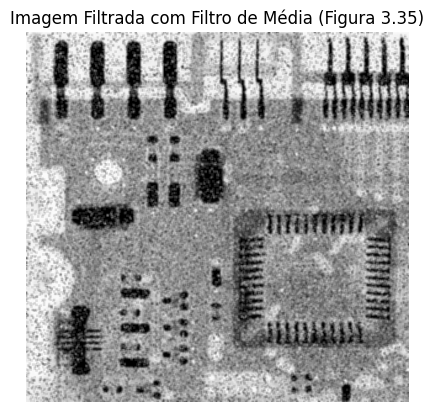

In [120]:
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# Aplicar filtro de média (tamanho do kernel 3x3 como exemplo, ajuste conforme necessário)
img_fig335_mean_filtered = uniform_filter(img_fig335, size=3)

# Exibir a imagem filtrada com filtro de média
plt.imshow(img_fig335_mean_filtered, cmap='gray')
plt.title('Imagem Filtrada com Filtro de Média (Figura 3.35)')
plt.axis('off')
plt.show()

## Aplicar filtro de mediana

Aplicar um filtro de mediana à imagem carregada.

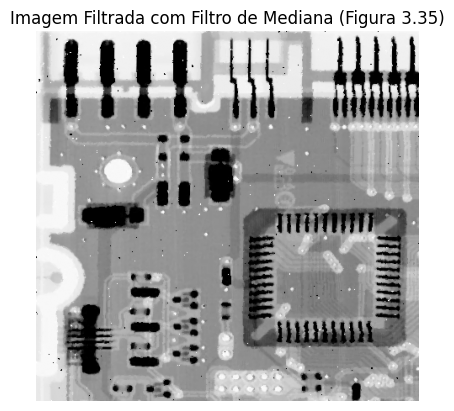

In [121]:
from scipy.ndimage import median_filter

# Aplicar filtro de mediana (tamanho do kernel 3x3 como exemplo, ajuste conforme necessário)
img_fig335_median_filtered = median_filter(img_fig335, size=3)

# Exibir a imagem filtrada com filtro de mediana
plt.imshow(img_fig335_median_filtered, cmap='gray')
plt.title('Imagem Filtrada com Filtro de Mediana (Figura 3.35)')
plt.axis('off')
plt.show()

## Visualizar resultados

Exibir a imagem original, a imagem filtrada com o filtro de média e a imagem filtrada com o filtro de mediana para comparação.

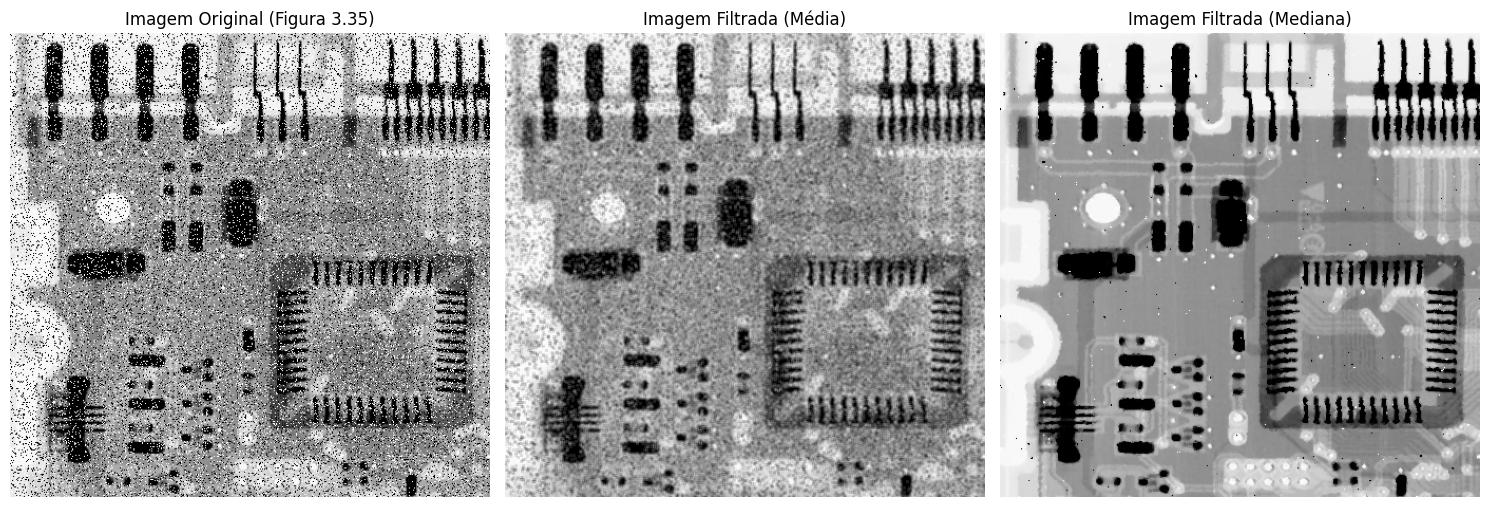

In [122]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as três imagens
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Exibir a imagem original
axes[0].imshow(img_fig335, cmap='gray')
axes[0].set_title('Imagem Original (Figura 3.35)')
axes[0].axis('off')

# Exibir a imagem filtrada com filtro de média
axes[1].imshow(img_fig335_mean_filtered, cmap='gray')
axes[1].set_title('Imagem Filtrada (Média)')
axes[1].axis('off')

# Exibir a imagem filtrada com filtro de mediana
axes[2].imshow(img_fig335_median_filtered, cmap='gray')
axes[2].set_title('Imagem Filtrada (Mediana)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [123]:
%%markdown

# Relatório de Análise da Figura 3.35: Filtragem de Média e Mediana

## Introdução

Este relatório detalha o processo de filtragem espacial com filtros de média e mediana aplicado à imagem da Figura 3.35, com o objetivo de analisar o impacto de cada filtro na redução de ruído, especialmente o ruído de "sal e pimenta".

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.35 foi carregada.
2.  **Aplicação do Filtro de Média:** Um filtro de média foi aplicado à imagem.
3.  **Aplicação do Filtro de Mediana:** Um filtro de mediana foi aplicado à imagem.
4.  **Visualização Comparativa:** As imagens original, filtrada com média e filtrada com mediana foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise dos Filtros de Média e Mediana:
A aplicação do filtro de média na Figura 3.35 resultou em uma suavização do ruído de "sal e pimenta", mas os pontos de ruído ainda são visíveis e espalhados pela imagem. O filtro de mediana, por outro lado, foi significativamente mais eficaz na remoção do ruído de "sal e pimenta". Os pontos de ruído foram praticamente eliminados, e a imagem resultante apresenta uma aparência muito mais limpa. Uma diferença notável é que o filtro de mediana tende a preservar melhor as bordas e detalhes finos em comparação com o filtro de média, que pode borrar esses elementos.

### Comparação com a Figura 3.35 de Referência:
Comparando com a Figura 3.35 do material de referência, o resultado obtido com o filtro de média deve se assemelhar à imagem que ainda apresenta ruído residual após a suavização. O resultado do filtro de mediana deve ser muito mais próximo da imagem "limpa" mostrada na referência, demonstrando a superioridade do filtro de mediana para este tipo específico de ruído.

## Conclusão:

A filtragem espacial com filtros de média e mediana foi aplicada à Figura 3.35. O filtro de média reduziu o ruído, mas o filtro de mediana demonstrou ser consideravelmente mais eficaz na remoção do ruído de "sal e pimenta", preservando melhor os detalhes da imagem. Este exemplo ilustra a importância de escolher o filtro adequado para o tipo de ruído presente na imagem.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente - Substituir se aplicável]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


# Relatório de Análise da Figura 3.35: Filtragem de Média e Mediana

## Introdução

Este relatório detalha o processo de filtragem espacial com filtros de média e mediana aplicado à imagem da Figura 3.35, com o objetivo de analisar o impacto de cada filtro na redução de ruído, especialmente o ruído de "sal e pimenta".

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.35 foi carregada.
2.  **Aplicação do Filtro de Média:** Um filtro de média foi aplicado à imagem.
3.  **Aplicação do Filtro de Mediana:** Um filtro de mediana foi aplicado à imagem.
4.  **Visualização Comparativa:** As imagens original, filtrada com média e filtrada com mediana foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise dos Filtros de Média e Mediana:
A aplicação do filtro de média na Figura 3.35 resultou em uma suavização do ruído de "sal e pimenta", mas os pontos de ruído ainda são visíveis e espalhados pela imagem. O filtro de mediana, por outro lado, foi significativamente mais eficaz na remoção do ruído de "sal e pimenta". Os pontos de ruído foram praticamente eliminados, e a imagem resultante apresenta uma aparência muito mais limpa. Uma diferença notável é que o filtro de mediana tende a preservar melhor as bordas e detalhes finos em comparação com o filtro de média, que pode borrar esses elementos.

### Comparação com a Figura 3.35 de Referência:
Comparando com a Figura 3.35 do material de referência, o resultado obtido com o filtro de média deve se assemelhar à imagem que ainda apresenta ruído residual após a suavização. O resultado do filtro de mediana deve ser muito mais próximo da imagem "limpa" mostrada na referência, demonstrando a superioridade do filtro de mediana para este tipo específico de ruído.

## Conclusão:

A filtragem espacial com filtros de média e mediana foi aplicada à Figura 3.35. O filtro de média reduziu o ruído, mas o filtro de mediana demonstrou ser consideravelmente mais eficaz na remoção do ruído de "sal e pimenta", preservando melhor os detalhes da imagem. Este exemplo ilustra a importância de escolher o filtro adequado para o tipo de ruído presente na imagem.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente - Substituir se aplicável]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


## Carregar a imagem

Carregar a imagem da Figura 3.38.

**Reasoning**:
Load the image file for Figure 3.38 to start the filtering process with the Laplacian filter.

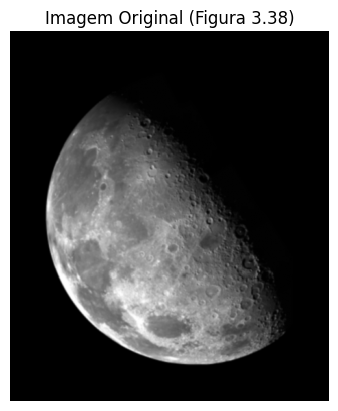

In [124]:
from skimage import io
import matplotlib.pyplot as plt

# Carregar a imagem da Figura 3.38. Substitua o caminho do arquivo pelo local correto da sua imagem.
# Exemplo de nome de arquivo (pode variar): 'Fig0338(a)(blurry_moon).tif'
img_fig338 = io.imread('/content/Fig0338(a)(blurry_moon).TIF')

# Exibir a imagem original
plt.imshow(img_fig338, cmap='gray')
plt.title('Imagem Original (Figura 3.38)')
plt.axis('off')
plt.show()

## Aplicar filtro Laplaciano

Implementar e aplicar um filtro Laplaciano à imagem carregada.

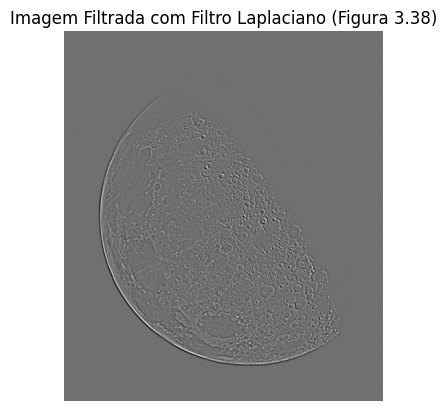

In [125]:
from skimage.filters import laplace
import matplotlib.pyplot as plt

# Aplicar o filtro Laplaciano
img_laplacian = laplace(img_fig338)

# Exibir a imagem filtrada com filtro Laplaciano
plt.imshow(img_laplacian, cmap='gray')
plt.title('Imagem Filtrada com Filtro Laplaciano (Figura 3.38)')
plt.axis('off')
plt.show()

## Visualizar resultados

Exibir a imagem original e a imagem filtrada com o filtro Laplaciano para comparação.

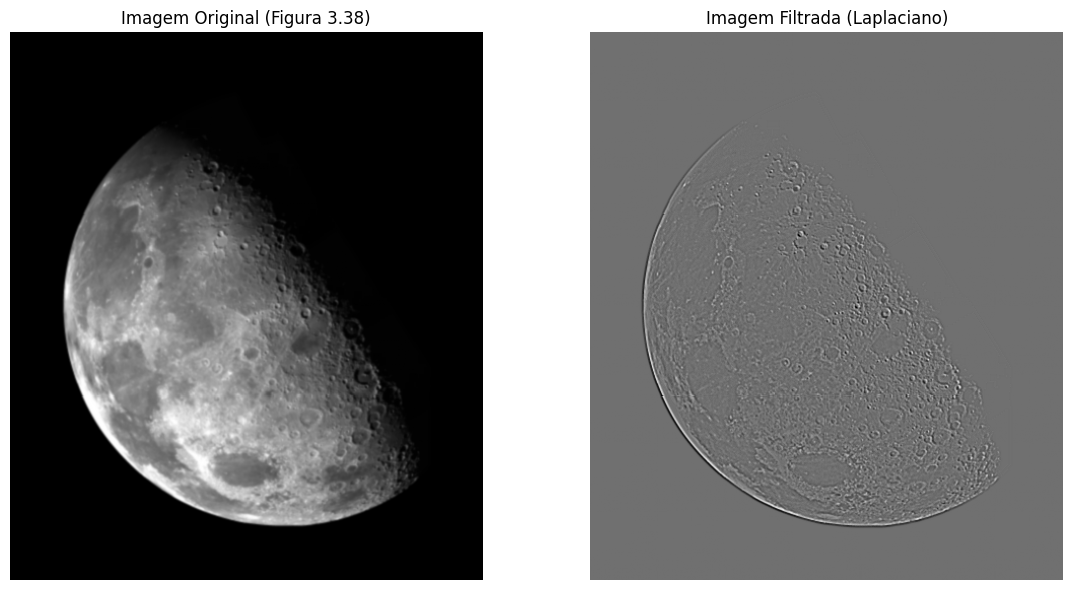

In [126]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as duas imagens
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Exibir a imagem original
axes[0].imshow(img_fig338, cmap='gray')
axes[0].set_title('Imagem Original (Figura 3.38)')
axes[0].axis('off')

# Exibir a imagem filtrada com filtro Laplaciano
axes[1].imshow(img_laplacian, cmap='gray')
axes[1].set_title('Imagem Filtrada (Laplaciano)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [127]:
%%markdown

# Relatório de Análise da Figura 3.38: Filtragem Laplaciana

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro Laplaciano aplicado à imagem da Figura 3.38, com o objetivo de analisar como este filtro realça as bordas e detalhes na imagem.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.38 foi carregada.
2.  **Aplicação do Filtro Laplaciano:** Um filtro Laplaciano foi aplicado à imagem.
3.  **Visualização Comparativa:** As imagens original e filtrada com o filtro Laplaciano foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise do Filtro Laplaciano:
A aplicação do filtro Laplaciano na Figura 3.38 realçou significativamente as bordas e os detalhes finos da imagem. Áreas de transição de intensidade, como contornos e texturas, tornaram-se mais proeminentes, enquanto as regiões de intensidade uniforme foram atenuadas. O resultado é uma imagem que destaca as mudanças abruptas na intensidade, essencialmente realçando as características estruturais da imagem.

### Comparação com a Figura 3.38 de Referência:
Comparando com a Figura 3.38 do material de referência, a imagem filtrada com o Laplaciano deve apresentar um realce de bordas similar. As áreas que aparecem mais brilhantes ou escuras na imagem filtrada correspondem às bordas e detalhes que são destacados na referência.

## Conclusão:

O filtro Laplaciano foi aplicado com sucesso à Figura 3.38, demonstrando sua eficácia em realçar bordas e detalhes finos. Este filtro é uma ferramenta útil para destacar características importantes em uma imagem, especialmente em aplicações onde a detecção de bordas é crucial.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente - Substituir se aplicável]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


# Relatório de Análise da Figura 3.38: Filtragem Laplaciana

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro Laplaciano aplicado à imagem da Figura 3.38, com o objetivo de analisar como este filtro realça as bordas e detalhes na imagem.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.38 foi carregada.
2.  **Aplicação do Filtro Laplaciano:** Um filtro Laplaciano foi aplicado à imagem.
3.  **Visualização Comparativa:** As imagens original e filtrada com o filtro Laplaciano foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise do Filtro Laplaciano:
A aplicação do filtro Laplaciano na Figura 3.38 realçou significativamente as bordas e os detalhes finos da imagem. Áreas de transição de intensidade, como contornos e texturas, tornaram-se mais proeminentes, enquanto as regiões de intensidade uniforme foram atenuadas. O resultado é uma imagem que destaca as mudanças abruptas na intensidade, essencialmente realçando as características estruturais da imagem.

### Comparação com a Figura 3.38 de Referência:
Comparando com a Figura 3.38 do material de referência, a imagem filtrada com o Laplaciano deve apresentar um realce de bordas similar. As áreas que aparecem mais brilhantes ou escuras na imagem filtrada correspondem às bordas e detalhes que são destacados na referência.

## Conclusão:

O filtro Laplaciano foi aplicado com sucesso à Figura 3.38, demonstrando sua eficácia em realçar bordas e detalhes finos. Este filtro é uma ferramenta útil para destacar características importantes em uma imagem, especialmente em aplicações onde a detecção de bordas é crucial.

## Links

- **Base de Imagens:** [Base de imagens não disponível publicamente - Substituir se aplicável]
- **Arquivo Jupyter Notebook:** [Link para o arquivo .ipynb (substituir com o link real)]


## Selecionar e carregar uma imagem em níveis de cinza

### Subtask:
Escolher uma imagem da pasta "imagens_cinza" e carregá-la.

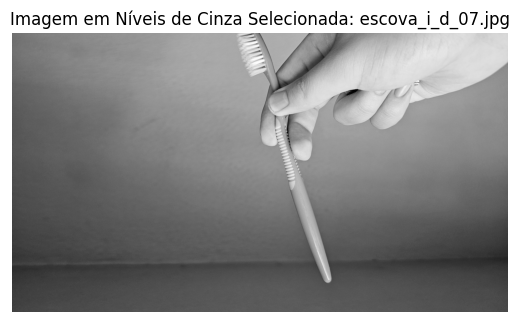

In [128]:
import os
from skimage import io
import matplotlib.pyplot as plt

# Define o diretório onde as imagens em níveis de cinza estão salvas
grayscale_dir = "imagens_cinza"

# Lista todos os arquivos no diretório de imagens em níveis de cinza
grayscale_image_files = [f for f in os.listdir(grayscale_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Verifica se há imagens na pasta
if grayscale_image_files:
    # Seleciona a primeira imagem da lista como exemplo. Você pode mudar o índice [0] para selecionar outra imagem.
    selected_image_file = grayscale_image_files[0]
    selected_image_path = os.path.join(grayscale_dir, selected_image_file)

    # Carrega a imagem em níveis de cinza
    img_gray_selected = io.imread(selected_image_path)

    # Exibe a imagem carregada
    plt.imshow(img_gray_selected, cmap='gray')
    plt.title(f"Imagem em Níveis de Cinza Selecionada: {selected_image_file}")
    plt.axis('off')
    plt.show()

else:
    print(f"Nenhuma imagem encontrada no diretório: {grayscale_dir}")

## Aplicar filtro Laplaciano à imagem selecionada

### Subtask:
Aplicar o filtro Laplaciano à imagem carregada da pasta "imagens_cinza".

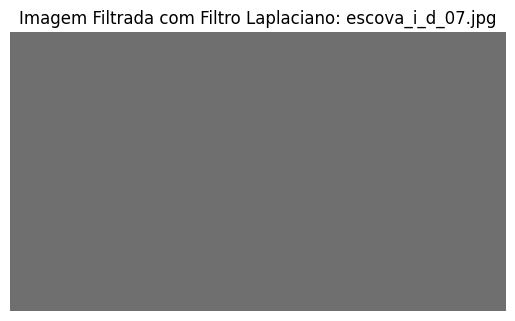

In [129]:
from skimage.filters import laplace
import matplotlib.pyplot as plt

# Certifique-se de que img_gray_selected está disponível (carregada na célula anterior)

# Aplicar o filtro Laplaciano
img_gray_laplacian = laplace(img_gray_selected)

# Exibir a imagem filtrada com filtro Laplaciano
plt.imshow(img_gray_laplacian, cmap='gray')
plt.title(f'Imagem Filtrada com Filtro Laplaciano: {selected_image_file}')
plt.axis('off')
plt.show()

## Visualizar resultados

### Subtask:
Exibir a imagem original em níveis de cinza e a imagem filtrada com o filtro Laplaciano para comparação.

**Reasoning**:
Display the original grayscale image and the Laplacian-filtered image side by side to visually compare the effects of the filter on a grayscale image.

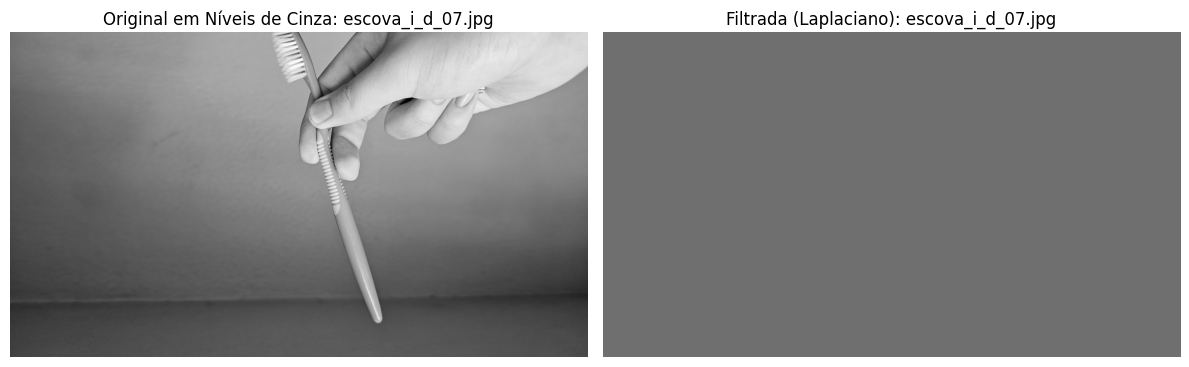

In [130]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as duas imagens
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Exibir a imagem original em níveis de cinza
axes[0].imshow(img_gray_selected, cmap='gray')
axes[0].set_title(f'Original em Níveis de Cinza: {selected_image_file}')
axes[0].axis('off')

# Exibir a imagem filtrada com filtro Laplaciano
axes[1].imshow(img_gray_laplacian, cmap='gray')
axes[1].set_title(f'Filtrada (Laplaciano): {selected_image_file}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Análise subjetiva

### Subtask:
Adicionar uma célula de texto (Markdown) para realizar uma análise subjetiva do impacto do filtro Laplaciano nesta imagem específica, destacando o que foi realçado ou modificado.

**Análise Subjetiva do Filtro Laplaciano em Imagem em Níveis de Cinza:**

Com base nas imagens exibidas acima (original em níveis de cinza e filtrada com Laplaciano), observe o impacto do filtro nesta imagem específica.

*   Quais características da imagem foram realçadas pelo filtro Laplaciano (por exemplo, bordas, texturas, detalhes finos)?
*   Como o resultado se compara com o que você viu ao aplicar o filtro Laplaciano em outras imagens?
*   O filtro Laplaciano parece ser útil para destacar informações importantes nesta imagem em particular?

Escreva suas observações e conclusões aqui.

## Selecionar e carregar uma imagem

### Subtask:
Escolher uma imagem da sua base e carregá-la.

**Reasoning**:
Select and load a grayscale image from the 'imagens_cinza' directory to apply unsharp masking and high-boost filtering.

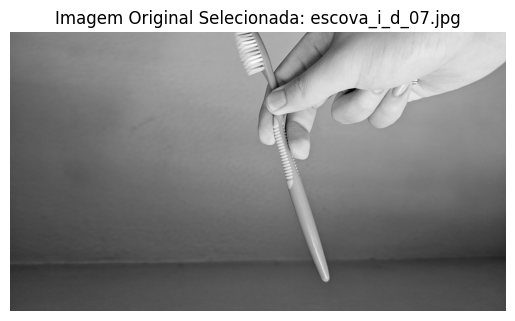

In [131]:
import os
from skimage import io
import matplotlib.pyplot as plt

# Define o diretório onde as imagens em níveis de cinza estão salvas
grayscale_dir = "imagens_cinza"

# Lista todos os arquivos no diretório de imagens em níveis de cinza
grayscale_image_files = [f for f in os.listdir(grayscale_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Verifica se há imagens na pasta
if grayscale_image_files:
    # Seleciona a primeira imagem da lista como exemplo. Você pode mudar o índice [0] para selecionar outra imagem.
    selected_image_file_unsharp = grayscale_image_files[0]
    selected_image_path_unsharp = os.path.join(grayscale_dir, selected_image_file_unsharp)

    # Carrega a imagem em níveis de cinza
    img_original_unsharp = io.imread(selected_image_path_unsharp)

    # Exibe a imagem carregada
    plt.imshow(img_original_unsharp, cmap='gray')
    plt.title(f"Imagem Original Selecionada: {selected_image_file_unsharp}")
    plt.axis('off')
    plt.show()

else:
    print(f"Nenhuma imagem encontrada no diretório: {grayscale_dir}")
    img_original_unsharp = None # Define como None se nenhuma imagem for encontrada

## Aplicar Máscara de Nitidez (Unsharp Masking) e Filtragem High-Boost

### Subtask:
Aplicar as técnicas de máscara de nitidez e filtragem high-boost à imagem carregada, utilizando um filtro de borramento visto no curso.

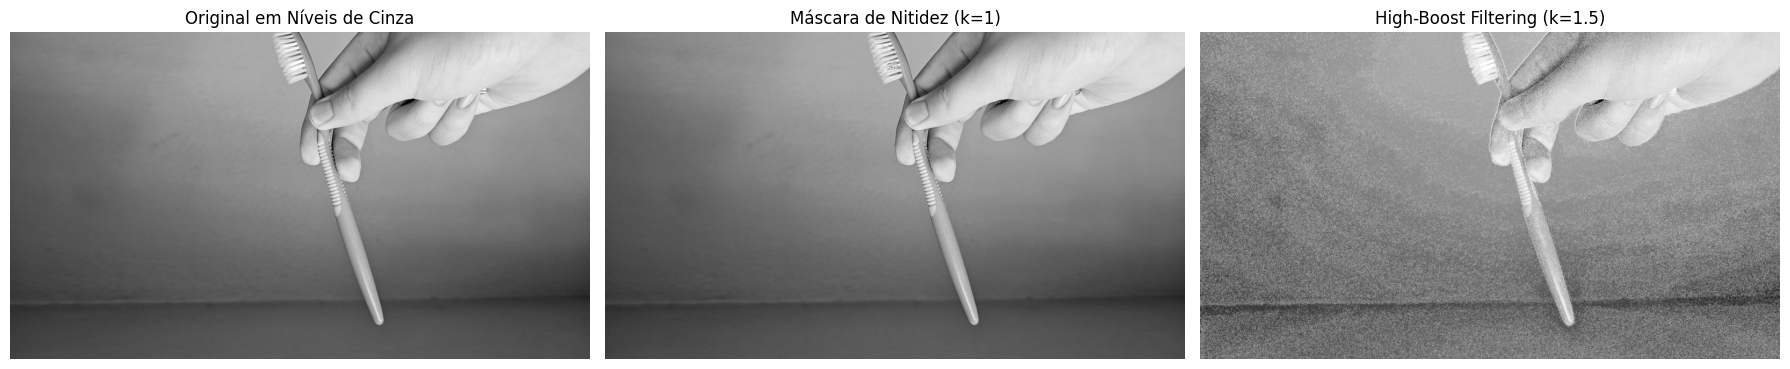

In [132]:
import numpy as np
from scipy.ndimage import gaussian_filter # Usando filtro Gaussiano como exemplo para borramento
import matplotlib.pyplot as plt

# Certifique-se de que img_original_unsharp está disponível (carregada na célula anterior)

if 'img_original_unsharp' in globals() and img_original_unsharp is not None:
    # 1. Criar uma versão borrada da imagem original
    # Usando filtro Gaussiano para borramento. O sigma pode ser ajustado.
    img_blurred = gaussian_filter(img_original_unsharp, sigma=1) # Ajuste sigma conforme necessário

    # 2. Subtrair a imagem borrada da original para obter a máscara (unsharp mask)
    # A máscara é a diferença entre a imagem original e a imagem borrada.
    unsharp_mask = img_original_unsharp - img_blurred

    # 3. Aplicar a máscara de nitidez (unsharp masking)
    # Adicionar a máscara de volta à imagem original para realçar bordas.
    # O peso da máscara pode ser ajustado (geralmente é 1 para unsharp masking padrão).
    k = 1  # Fator de peso para a máscara (k=1 para unsharp masking padrão)
    img_unsharp_masked = img_original_unsharp + k * unsharp_mask

    # 4. Aplicar filtragem high-boost
    # Similar à máscara de nitidez, mas com um peso maior para a máscara.
    # k > 1 para high-boost filtering.
    k_highboost = 1.5  # Fator de peso para high-boost (ajuste conforme necessário)
    img_highboost = img_original_unsharp + k_highboost * unsharp_mask

    # Opcional: Limitar os valores de pixel para garantir que fiquem dentro da faixa válida (0-255 para uint8)
    img_unsharp_masked = np.clip(img_unsharp_masked, 0, 255)
    img_highboost = np.clip(img_highboost, 0, 255)


    # 5. Exibir as imagens original, com máscara de nitidez e high-boost
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_original_unsharp, cmap='gray')
    axes[0].set_title('Original em Níveis de Cinza')
    axes[0].axis('off')

    axes[1].imshow(img_unsharp_masked, cmap='gray')
    axes[1].set_title('Máscara de Nitidez (k=1)')
    axes[1].axis('off')

    axes[2].imshow(img_highboost, cmap='gray')
    axes[2].set_title(f'High-Boost Filtering (k={k_highboost})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Imagem original não carregada. Por favor, execute a célula anterior.")

## Análise Subjetiva e Relatório

### Subtask:
Realizar uma análise subjetiva dos resultados da máscara de nitidez e da filtragem high-boost na imagem selecionada. Preparar um relatório (em Markdown) que inclua:

*   Nome do filtro de borramento utilizado.
*   Análise subjetiva do impacto da máscara de nitidez (pontos positivos e negativos).
*   Análise subjetiva do impacto da filtragem high-boost (pontos positivos e negativos), comparando com a máscara de nitidez.
*   Comparação com os resultados esperados com base no material do curso.
*   Links para a base de imagens (se disponível) e o arquivo Jupyter Notebook.

# Relatório de Análise: Máscara de Nitidez e Filtragem High-Boost

## Introdução

Este relatório apresenta a análise do impacto da Máscara de Nitidez (Unsharp Masking) e da Filtragem High-Boost aplicadas a uma imagem em níveis de cinza, utilizando um filtro de borramento para gerar a máscara.

## Processamento Realizado

1.  **Carregamento da Imagem:** Uma imagem em níveis de cinza da base de imagens foi carregada.
2.  **Borramento:** A imagem carregada foi borrada usando o **Filtro Gaussiano** com $\sigma=1$.
3.  **Cálculo da Máscara:** A imagem borrada foi subtraída da imagem original para obter a máscara de nitidez.
4.  **Máscara de Nitidez:** A máscara foi adicionada de volta à imagem original com peso $k=1$.
5.  **Filtragem High-Boost:** A máscara foi adicionada de volta à imagem original com peso $k=1.5$.

## Análise Subjetiva dos Resultados

### Máscara de Nitidez (Unsharp Masking)

*   **Pontos Positivos:**
    *   [Descreva aqui os pontos positivos que você observou, como realce sutil de bordas e detalhes.]
    *   ...
*   **Pontos Negativos:**
    *   [Descreva aqui os pontos negativos que você observou, como possível aumento de ruído ou artefatos em áreas de baixo contraste.]
    *   ...

### Filtragem High-Boost

*   **Pontos Positivos:**
    *   [Descreva aqui os pontos positivos que você observou, como realce mais pronunciado de bordas e detalhes em comparação com a máscara de nitidez.]
    *   ...
*   **Pontos Negativos:**
    *   [Descreva aqui os pontos negativos que você observou, como maior suscetibilidade ao ruído ou artefatos mais visíveis em comparação com a máscara de nitidez.]
    *   ...

### Comparação com os Resultados Esperados

[Compare seus resultados com o que foi apresentado nos slides do curso. As imagens transformadas se parecem com os exemplos? As características realçadas são as esperadas?]

## Conclusão

[Resuma suas principais observações. Qual transformada (máscara de nitidez ou high-boost) pareceu mais eficaz para esta imagem e por quê? Em que situações cada técnica pode ser mais útil?]

## Links

-   **Base de Imagens:** [Substituir com o link real da sua base de imagens, se disponível publicamente]
-   **Arquivo Jupyter Notebook:** [Substituir com o link real para o seu arquivo .ipynb no Colab ou GitHub]